In [1]:
!pip install uproot
import uproot

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 397.5/397.5 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 925.8/925.8 kB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.3/689.3 kB 34.3 MB/s eta 0:00:00


In [11]:
!pip install awkward
import awkward as ak

In [15]:
!pip install awkward_pandas

standard PET - two-gamma anhilation

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import awkward as ak

rootfile = uproot.open('merged.root')
print(rootfile.keys())

['TwoG_NCS;1', 'TwoG_PhantomSCS;1', 'TwoG_ScannerSCS;1', 'TwoG_PhantomSCS_ScannerSCS;1', 'TwoG_PhantomDCS;1', 'TwoG_ScannerDCS;1', 'TwoG_PhantomSCS_ScannerDCS;1', 'TwoG_PhantomDCS_ScannerSCS;1', 'TwoG_PhantomDCS_ScannerDCS;1', 'TwoG_MCS;1', 'TwoG_Excluded;1', 'ThreeG_NCS;1', 'ThreeG_ScannerSCS;1', 'ThreeG_ScannerDCS;1', 'ThreeG_ScannerTCS;1', 'ThreeG_MCS;1', 'ThreeG_Excluded;1']


In [5]:
for key in rootfile.keys():
    obj = rootfile[key]
    if hasattr(obj, "num_entries"):
        print(key, obj.num_entries)

TwoG_NCS;1 42062
TwoG_PhantomSCS;1 26934
TwoG_ScannerSCS;1 136764
TwoG_PhantomSCS_ScannerSCS;1 56968
TwoG_PhantomDCS;1 3312
TwoG_ScannerDCS;1 99240
TwoG_PhantomSCS_ScannerDCS;1 24520
TwoG_PhantomDCS_ScannerSCS;1 4225
TwoG_PhantomDCS_ScannerDCS;1 1506
TwoG_MCS;1 547171
TwoG_Excluded;1 0
ThreeG_NCS;1 0
ThreeG_ScannerSCS;1 0
ThreeG_ScannerDCS;1 0
ThreeG_ScannerTCS;1 0
ThreeG_MCS;1 0
ThreeG_Excluded;1 0


In [26]:
tree = rootfile['TwoG_ScannerSCS']
print(tree.keys())

['EventID', 'CoincidenceType', 'CoincidenceTypeName', 'NGammas', 'AnnihilX_mm', 'AnnihilY_mm', 'AnnihilZ_mm', 'GammaIndex', 'GammaTrackID', 'GammaParentID', 'HitIndex', 'VolumeID', 'VolumeName', 'ProcessID', 'ProcessName', 'EnergyDeposit_keV', 'PreEnergy_keV', 'PostEnergy_keV', 'X_mm', 'Y_mm', 'Z_mm', 'Theta_deg', 'Phi_deg', 'DeltaPhi01_deg', 'DeltaPhi02_deg', 'DeltaPhi12_deg']


In [16]:
import uproot
import pandas as pd
import matplotlib.pyplot as plt

filename = "merged.root"
tree_name = "TwoG_NCS"

file = uproot.open(filename)
tree = file[tree_name]

df = tree.arrays(library="pd")

print(df.head())
print(df.columns)

   EventID  CoincidenceType  CoincidenceTypeName  NGammas  AnnihilX_mm  \
0       14                0             TwoG_NCS        2    -0.569898   
1       14                0             TwoG_NCS        2    -0.569898   
2       18                0             TwoG_NCS        2     3.877718   
3       18                0             TwoG_NCS        2     3.877718   
4       26                0             TwoG_NCS        2     2.400055   

   AnnihilY_mm  AnnihilZ_mm  GammaIndex  GammaTrackID  GammaParentID  ...  \
0     2.368709    -5.295002           0             3              1  ...   
1     2.368709    -5.295002           1             2              1  ...   
2     4.785067    -7.613710           0             3              1  ...   
3     4.785067    -7.613710           1             2              1  ...   
4    -0.319345   -12.199783           0             3              1  ...   

   PreEnergy_keV  PostEnergy_keV       X_mm       Y_mm       Z_mm  Theta_deg  \
0     510.99

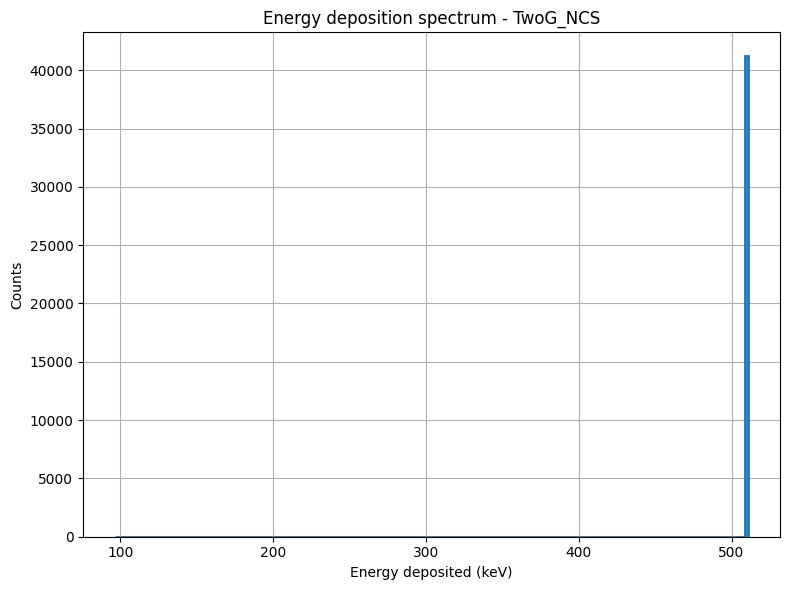

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.hist(df["EnergyDeposit_keV"],
         bins=200,
         histtype="step",
         linewidth=2)

plt.xlabel("Energy deposited (keV)")
plt.ylabel("Counts")
plt.title("Energy deposition spectrum - TwoG_NCS")

plt.grid(True)

plt.tight_layout()
plt.show()

this is expected as there is no scattering - dummy check that the simulation has worked

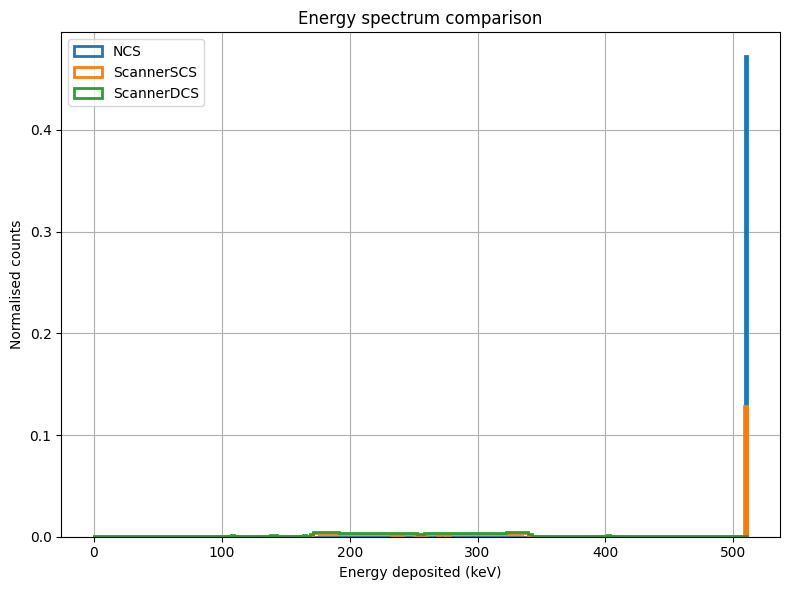

In [20]:
tree1 = file["TwoG_NCS"].arrays(library="pd")
tree2 = file["TwoG_ScannerSCS"].arrays(library="pd")
tree3 = file["TwoG_ScannerDCS"].arrays(library="pd")

plt.figure(figsize=(8,6))

plt.hist(tree1["EnergyDeposit_keV"],
         bins=200,
         histtype="step",
         linewidth=2,
         density=True,
         label="NCS")

plt.hist(tree2["EnergyDeposit_keV"],
         bins=200,
         histtype="step",
         linewidth=2,
         density=True,
         label="ScannerSCS")

plt.hist(tree3["EnergyDeposit_keV"],
         bins=200,
         histtype="step",
         linewidth=2,
         density=True,
         label="ScannerDCS")

plt.xlabel("Energy deposited (keV)")
plt.ylabel("Normalised counts")
plt.title("Energy spectrum comparison")

plt.legend()

plt.grid(True)

plt.tight_layout()
plt.show()

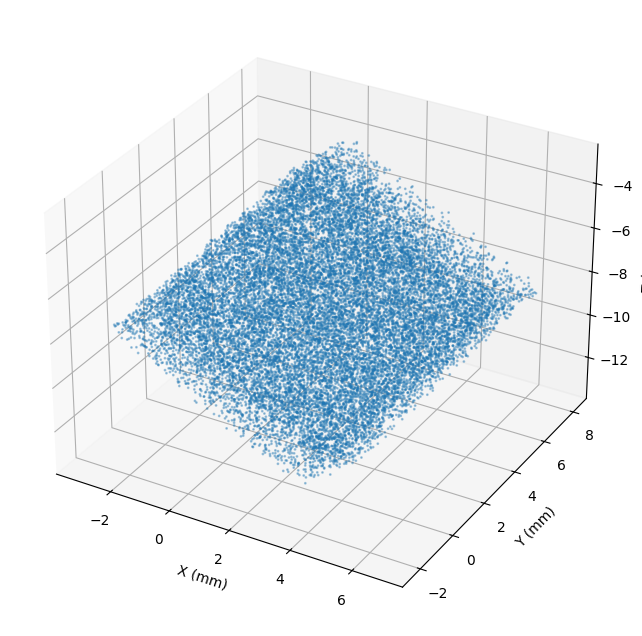

In [24]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

treeSCS = file["TwoG_ScannerSCS"]

data = tree.arrays(library="pd")

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(data["AnnihilX_mm"],
           data["AnnihilY_mm"],
           data["AnnihilZ_mm"],
           s=1,
           alpha=0.2)

ax.set_xlabel("X (mm)")
ax.set_ylabel("Y (mm)")
ax.set_zlabel("Z (mm)")

plt.show()

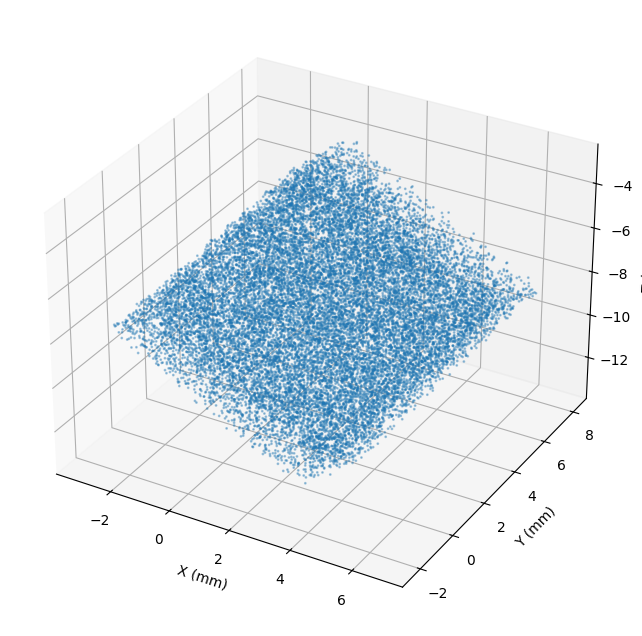

In [25]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

treeDCS = file["TwoG_ScannerDCS"]

data = tree.arrays(library="pd")

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(data["AnnihilX_mm"],
           data["AnnihilY_mm"],
           data["AnnihilZ_mm"],
           s=1,
           alpha=0.2)

ax.set_xlabel("X (mm)")
ax.set_ylabel("Y (mm)")
ax.set_zlabel("Z (mm)")

plt.show()